# Lab 02: Where Is the Star, and How Sure Are You Allowed to Be?

**ASTR 457, Fall 2026, posted Thu Sep 10, due Wed Sep 16 by Noon (fork → PR, as always)**

*Why this lab: centroiding is how every position in every catalog you'll ever use was measured, and the Cramér–Rao bound is the professional's sanity check (the best precision any measurement can claim) that tells you instantly when an error bar in a paper (or from an AI) is too good to be true.*

Every one of you has your own dataset: `data/<your netid>.csv`, with a single column `x`,
the arrival positions, in pixels, of individual photons on a 1-D detector window spanning
$[0, 64]$ px. Most of the photons come from a star whose image on the detector is a Moffat
profile centered at $x_0$, with shape parameters $\beta = 2.5$ and $r_0 = 4$ px (both known
to you). The rest are **background**: a fraction $f_{\rm bg}$ of the photons, spread uniformly
across the window. I know the true $x_0$ and $f_{\rm bg}$ for your dataset. You don't, and you
can't look them up, and your classmates' values are different from yours. (So are their photon
counts, so your Part 2 bound is yours alone.)

**How this is graded.** Not on whether your code runs, but on whether your answers are *right*
and your uncertainties are *honest*. Part of your grade comes from how close your reported
$x_0$ and $f_{\rm bg}$ are to your truth **in units of your own reported uncertainty**. Report
tiny error bars you can't back up and you will lose points even if your central value is close.
Report huge error bars to be safe and you'll lose points too. Calibration is the skill.
And this week there is a floor under "huge": your reported $\sigma_{x_0}$ may not exceed
**3× the Cramér–Rao bound** you compute in Part 2. An error bar bigger than that is not
caution, since it's an estimator you should have discarded.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and document
it in Part 4. You may be selected to defend this lab in person. Welcome to doing research.

## Part 1: The naive estimator (15%)

Load your photon list and plot a histogram of the arrival positions (choose your binning
deliberately, and you'll defend it). Then estimate the star's position the obvious way: the
**sample mean** of all the photon positions, with uncertainty $s/\sqrt{N}$ (the standard
error of the mean). Report $\hat{x}_0 \pm \sigma$.

Then answer, in a few sentences: is this estimator biased for *your* dataset, and why?
Which way does the bias pull, and what controls its size? (This estimator is *supposed* to
be biased. Understanding exactly how (and what the background has to do with it) is the
point.)

In [3]:
# Part 1: your work here
import numpy as np
import pandas as pd
import astropy 

from scipy.stats import t as student_t
from scipy.optimize import minimize

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
data = np.genfromtxt('../../labs/02/data/zahisr2.csv', delimiter=',', names = True)
df = pd.DataFrame(data)
df.head()

,x
0,40.480109
1,31.412180
2,2.349791
3,39.336231
4,0.017046


In [5]:
print("Data Summary:")
df.describe()

Data Summary:


,x
count,587.000000
mean,28.102775
std,11.605747
min,0.017046
25%,23.789243
50%,26.137974
75%,29.286632
max,63.819663


In [6]:
x = df.x
xhat0 = x.mean() #sample mean
n = len(x)
sigma = x.std() / np.sqrt(n)

28.102775218057925 +- 0.47902044135802596


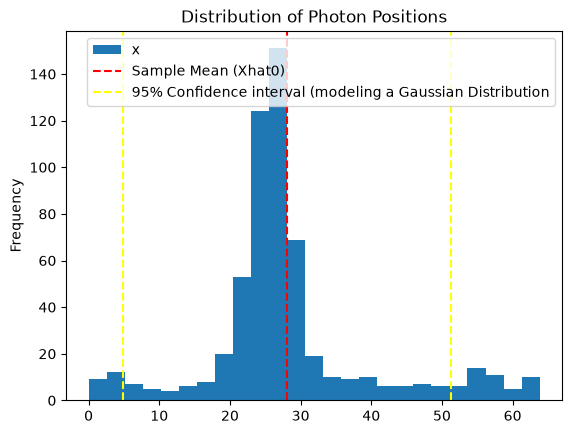

In [7]:
print(xhat0, "+-", sigma)
df.plot.hist(bins = 25) #chose 25 because common practice is around sqrt(n) which is ~ 24. There was also little important visual differences between 24-30 bins.
plt.axvline(xhat0, color = 'red', linestyle = "--", label = "Sample Mean (Xhat0)")
plt.axvline(xhat0 - 2 * x.std(), color = 'yellow', linestyle = "--", label = "95% Confidence interval (modeling a Gaussian Distribution")
plt.axvline(xhat0 + 2 * x.std(), color = 'yellow', linestyle = "--")
plt.legend()
plt.title("Distribution of Photon Positions");

**ANSWER (a few sentences):**

Initial analysis shows the distribution to be slightly right skewed, with a central peak around 26 px. That 26 is closer to to the median of the distribution, rather than the sample mean of around 28 px. We can see that this mean slightly overestimates the central peak on the plot. We also plot the 95.5% interval for the expected spread of the data as if it were a gaussian (by using the .std() function), but we must acknowledge that the distribution is a Moffat profile with the given parameters above.

**$\hat{x}_0 \pm \sigma$ = 28.1028 +- 0.4790**

The background photons are uniformly distributed with a fraction of all background photons to all photons being fbg. Their center is 32, so if the peak of the total distribution is under that point as observed, the sample mean sits somewhere in between the upper bound of 32 and the lower bound, the true x0. Therefore xhat0 overestimates x0 because of the pull of the background photons.

## Part 2: Estimators you can defend (40%)

Now do it properly. Estimate $x_0$ **three more ways** and compare:

1. **The median** of the photon positions. Robust, simple, but is it unbiased here, and
   what is its variance? (You may answer the variance question empirically in Part 3.)
2. **A sigma-clipped mean**: iteratively remove photons far from the current estimate,
   re-estimate, repeat until it converges. Be explicit about your clipping threshold and
   why you chose it.
3. **Maximum likelihood on the mixture model.** Each photon is background with probability
   $f_{\rm bg}$, or from the star otherwise, so the probability density for a single photon at
   position $x$ is

   $$p(x \mid x_0, f_{\rm bg}) \;=\; \frac{f_{\rm bg}}{64} \;+\; (1 - f_{\rm bg})\,
   \frac{\Gamma(\beta)}{r_0\sqrt{\pi}\,\Gamma(\beta - \tfrac{1}{2})}
   \left[1 + \left(\frac{x - x_0}{r_0}\right)^2\right]^{-\beta}$$

   with $\beta = 2.5$ and $r_0 = 4$ px. Maximize $\sum_i \ln p(x_i \mid x_0, f_{\rm bg})$ over
   both parameters (see Ivezić, Connolly, VanderPlas & Gray, §4.2, for the machinery; this
   is the same likelihood game with different symbols). Get uncertainties from the curvature
   of the log-likelihood at its peak (the observed information), and say so.

Then compute the **Cramér–Rao bound**: the smallest variance any unbiased estimator of $x_0$
can achieve given your $N$ photons. The per-photon Fisher information
$I(x_0) = \int \frac{1}{p}\left(\frac{\partial p}{\partial x_0}\right)^2 dx$ is yours to
evaluate (numerically over the window is fine) and the bound is
$\sigma_{x_0} \geq 1/\sqrt{N\,I}$. Treat both parameters as unknown: the honest bound comes
from inverting the $2\times 2$ Fisher matrix, not the $x_0$ term alone. How close does each
of your four estimators get?

(Two technicalities you may use without proof: photons landing outside the window were lost,
but for your $x_0$ the lost fraction is negligible, and checking that claim makes a fine
Part 3 sensitivity test. And for simulating: a 1-D Moffat with exponent $\beta$ is a
Student-$t$ distribution with $\nu = 2\beta - 1$ degrees of freedom, scaled by
$r_0/\sqrt{\nu}$.)

Commit to a **final answer**, one $x_0 \pm \sigma$ and $f_{\rm bg} \pm \sigma$ you'd put in
a paper, and justify the choice. State clearly how you estimated your uncertainties and why
you believe them. Remember the 3× rule from the header.

In [10]:
# Part 2: your work here
xhat0_median = x.median()
print(f"Median: x0 = {xhat0_median:.4f}")

Median: x0 = 26.1380


In [11]:
k = 3
mask = np.ones_like(x, dtype=bool)

for i in range(10):
    center = np.mean(x[mask])                   
    resid_retained = x[mask] - center
    mad = np.median(np.abs(resid_retained - np.median(resid_retained)))
    scale = 1.4826 * mad                           
    
    full_resid = x - center                        
    new_mask = np.abs(full_resid) / scale < k
    if np.array_equal(new_mask, mask):
        break
    mask = new_mask

xhat0_clip = np.mean(x[mask])
sigma_clip = np.std(x[mask], ddof=1) / np.sqrt(mask.sum())   
outlier_fraction_clip = (len(x) - mask.sum()) / len(x)

print(f"Sigma-clipped mean: x0 = {xhat0_clip:.4f} +- {sigma_clip:.4f}")
print(f"Outlier fraction: {outlier_fraction_clip:.4f}")

Sigma-clipped mean: x0 = 25.8034 +- 0.1337
Outlier fraction: 0.2658


In [12]:
beta, r0, window = 2.5, 4.0, 64.0
nu = 2*beta - 1          # = 4
scale = r0/np.sqrt(nu)   # = 2.0

def mixture_pdf(x, x0, f_bg):
    star = student_t.pdf(x, df=nu, loc=x0, scale=scale)   # given that student-t is equivalent to moffat
    bg = 1.0/window                                        
    return f_bg*bg + (1-f_bg)*star

def neg_log_likelihood(theta, x):
    x0, f_bg = theta
    f_bg = np.clip(f_bg, 1e-6, 1-1e-6)   
    p = mixture_pdf(x, x0, f_bg)
    return -np.sum(np.log(p + 1e-300))

theta0 = [xhat0_clip, 0.2]   
result = minimize(neg_log_likelihood, theta0, args=(x,), method='BFGS')

xhat0_mle, fbg_mle = result.x
cov_mle = result.hess_inv
sigma_mle, sigma_fbg_mle = np.sqrt(np.diag(cov_mle))

print(f"Mixture MLE: x0 = {xhat0_mle:.4f} +- {sigma_mle:.4f}")
print(f"f_bg = {fbg_mle:.4f} +- {sigma_fbg_mle:.4f}")

Mixture MLE: x0 = 25.8626 +- 0.1314
f_bg = 0.3369 +- 0.0242


In [13]:
def score_functions(x, x0, f_bg, h=1e-5):
    p = mixture_pdf(x, x0, f_bg)
    dpdx0  = (mixture_pdf(x, x0 + h, f_bg) - mixture_pdf(x, x0 - h, f_bg)) / (2*h)
    dpdfbg = (mixture_pdf(x, x0, f_bg + h) - mixture_pdf(x, x0, f_bg - h)) / (2*h)
    return p, dpdx0, dpdfbg

from scipy.integrate import quad

def fisher_integrand(x, x0, f_bg, i, j):
    p, dpdx0, dpdfbg = score_functions(x, x0, f_bg)
    derivs = (dpdx0, dpdfbg)
    return derivs[i] * derivs[j] / p

In [15]:
I_single = np.zeros((2, 2))
for i in range(2):
    for j in range(2):
        I_single[i, j], _ = quad(fisher_integrand, 0, 64, args=(xhat0_mle, fbg_mle, i, j))

I_total = len(x) * I_single
cov_CRB = np.linalg.inv(I_total)     
sigma_CRB, sigma_fbg_CRB = np.sqrt(np.diag(cov_CRB))

print(f"Cramer-Rao bound: sigma_x0 >= {sigma_CRB:.4f} px")
print(f"Cramer-Rao bound: sigma_fbg >= {sigma_fbg_CRB:.4f}")
print(f"3x CRB ceiling on your reported sigma_x0: {3*sigma_CRB:.4f} px")

Cramer-Rao bound: sigma_x0 >= 0.1302 px
Cramer-Rao bound: sigma_fbg >= 0.0236
3x CRB ceiling on your reported sigma_x0: 0.3906 px


In [23]:
comparison = pd.DataFrame({
    "Estimator": ["Sample mean", "Median", "Sigma-clipped mean", "Mixture MLE"],
    "x0_hat": [xhat0, xhat0_median, xhat0_clip, xhat0_mle],
    "sigma_x0": [sigma, np.nan, sigma_clip, sigma_mle],
    "sigma_x0 / CRB": [sigma/sigma_CRB, np.nan, sigma_clip/sigma_CRB, sigma_mle/sigma_CRB],
})
comparison

,Estimator,x0_hat,sigma_x0,sigma_x0 / CRB
0,Sample mean,28.102775,0.479020,3.679376
1,Median,26.137974,NaN,NaN
2,Sigma-clipped mean,25.803378,0.133725,1.027145
3,Mixture MLE,25.862617,0.131448,1.009661


**FINAL ANSWER:** $x_0 = $ 25.862617 $\pm$ 0.131448 px , $f_{\rm bg} = $ ___ $\pm$ 0.131448 , Cramér–Rao bound $\sigma_{x_0}^{\rm CRB} = $ 1.009661 px

**Justification and uncertainty method (a short paragraph):**

The reported estimates come from the maximum likelyhood estimator. From earlier, this estimate is lower than the sample mean of 28 which we knew to overestimate $x_0$, meaning our new estimate accounts for the bias from part 1. Since the median does not provide a $sigma_{x_0}$ and the sigma clipped mean depends on a k that we must choose ourselves, the MLE method proves to be the most justified to use in this case. All that is needed is the already given shape of the background and the signal (Mofat) with given parameters like $Beta$ and $r_0$. Furthermore, the Mixture MLE results and the sigma-clipped mean results are marginally similar so choosing the model with the least amount of assumtions by myself may be the most reliable choice. Regarding the CRB, the sample mean is around 4 times the floor, while our chosen Mixture MLE is within 1% of the floor, reinforcing our choice to use it as our final answer.

## Part 3: The verification plan, written first and then executed (35%)

This is the headline of this lab. **Before you run anything below, write the plan** (3a).
A verification plan you invent after seeing the results is a rationalization.

**3a. The plan.** List the checks you will run to decide whether to trust your Part 2
numbers. At minimum, address:

1. **Closure**: simulate a dataset with a truth *you* choose (the Student-$t$ fact from
   Part 2 makes this easy) and confirm your estimator recovers it.
2. **Bias and efficiency**: Monte Carlo all four estimators on many simulated datasets at
   plausible parameters. Plot their bias and their variance against the Cramér–Rao bound.
   This is *the* figure of this lab.
3. **Coverage**: across your simulations, do your 68% intervals contain the truth 68% of
   the time?
4. **Sensitivity**: what happens to your $\hat{x}_0$ if $\beta$ or $r_0$ are slightly wrong,
   or if the lost-photon fraction isn't negligible after all?

For **each** check, state *in advance* what failure would look like. A check that cannot
fail is not a check.

**3b. The execution.** Run the plan. Report what each check found, including anything that
failed or surprised you. A failed check honestly reported and diagnosed is worth more than
a wall of green checkmarks.

**VERIFICATION PLAN (write this before running 3b):**

*your plan goes here*

In [ ]:
# Part 3b: execute the plan here

**WHAT THE CHECKS FOUND:**

*your report goes here*

## Part 4: AI-use appendix (10%)

**AI use**: which tools did you use (Copilot, Claude, ChatGPT, none, ...), for what,
what did they get wrong, and how did you catch it? Honesty is graded; "I didn't use any"
is fine if true. (Your verification plan lives in Part 3 this week; it earned a
promotion. If an AI wrote any of it, that belongs here too.)

**AI-USE APPENDIX:**

*your answer goes here*